In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv(r'C:\Infoct_project 1 sample practice\dataset\predictive_maintenance.csv')
print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(10000, 10)


In [3]:
# Week 2 external context
np.random.seed(42)
df['Ambient_temperature'] = np.random.normal(loc=295, scale=3, size=len(df))
df['Load_density'] = np.random.uniform(low=0.3, high=1.0, size=len(df))

# Week 1 engineered features
df["temp_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
df["tool_wear_rate"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"]
df["heat_stress_index"] = df["Air temperature [K]"] * df["Tool wear [min]"]
df["wear_per_rotation"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"] * 1000

# Week 3 Day 1 new features
df["thermal_stress"] = df["temp_difference"] * df["tool_wear_rate"]
df["power_per_temp"] = df["power"] / df["Air temperature [K]"]

print("All features recreated!")
print(df.shape)

All features recreated!
(10000, 19)


In [4]:
# Final 12 features
final_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]','temp_difference', 'power', 'tool_wear_rate',
'heat_stress_index', 'wear_per_rotation','thermal_stress', 'power_per_temp']
X = df[final_features]
Y = df['Target']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, Y_train)

print("Model trained successfully!")
print(f"Macro F1 Score: {f1_score(Y_test, model.predict(X_test_scaled), average='macro'):.3f}")


[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model trained successfully!
Macro F1 Score: 0.899


c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': final_features,
    'importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    'importance', ascending=False).reset_index(drop=True)

feature_importance['rank'] = range(1, len(feature_importance) + 1)

print("=== Feature Importance Ranking ===")
print(feature_importance[['rank', 'feature', 'importance']])

=== Feature Importance Ranking ===
    rank                  feature  importance
0      1   Rotational speed [rpm]         392
1      2                    power         380
2      3              Torque [Nm]         352
3      4          Tool wear [min]         312
4      5          temp_difference         297
5      6  Process temperature [K]         274
6      7           power_per_temp         254
7      8      Air temperature [K]         229
8      9           thermal_stress         188
9     10           tool_wear_rate         186
10    11        heat_stress_index         136
11    12        wear_per_rotation           0


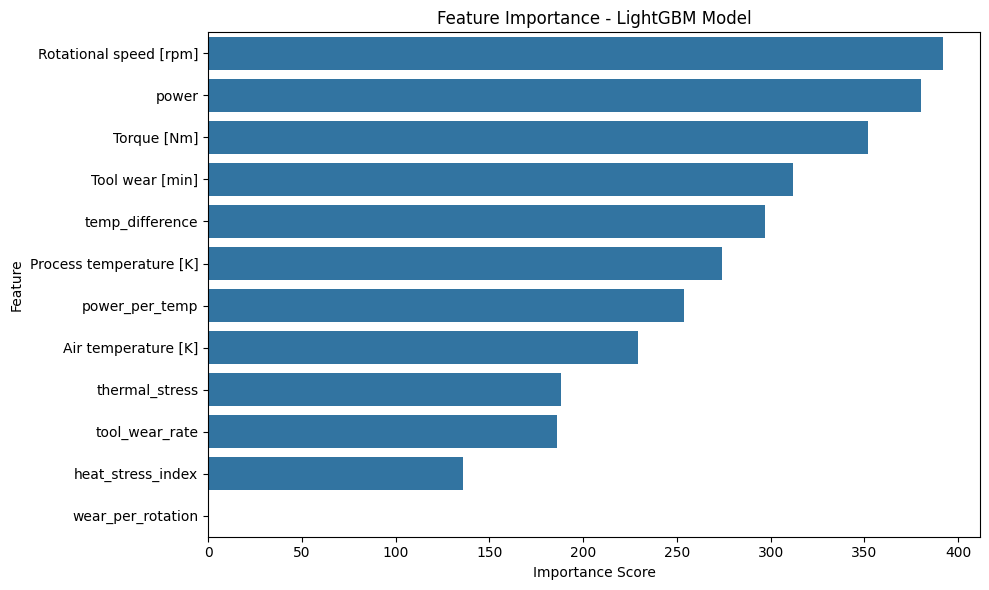

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - LightGBM Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(r'C:\Infoct_project 1 sample practice\Week3_Yogesh\feature_importance.png')
plt.show()

In [7]:
# Separate original vs engineered features
original_features = ['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

engineered_features = ['temp_difference', 'power', 'tool_wear_rate','heat_stress_index', 'wear_per_rotation','thermal_stress', 'power_per_temp']

# Calculate total importance
original_imp = feature_importance[
    feature_importance['feature'].isin(original_features)]['importance'].sum()

engineered_imp = feature_importance[
    feature_importance['feature'].isin(engineered_features)]['importance'].sum()

total_imp = original_imp + engineered_imp

print("=== Fusion Feature Impact Analysis ===")
print(f"Original sensors importance: {original_imp} ({original_imp/total_imp*100:.1f}%)")
print(f"Engineered features importance: {engineered_imp} ({engineered_imp/total_imp*100:.1f}%)")
print(f"Total importance: {total_imp}")

=== Fusion Feature Impact Analysis ===
Original sensors importance: 1559 (52.0%)
Engineered features importance: 1441 (48.0%)
Total importance: 3000


In [8]:
print("=== Business Interpretation ===")
print()
print("Top 3 failure indicators for factory managers:")
print()
print("1. Rotational Speed (Most Important - 392)")
print("   → When machine spins unusually fast or slow = failure risk!")
print()
print("2. Power (Second Most Important - 380)")
print("   → High power consumption = machine overloaded = failure coming!")
print()
print("3. Torque (Third Most Important - 352)")
print("   → Unusual force applied = machine struggling = failure risk!")
print()
print("Key insight:")
print("→ Engineered features contribute 48% of model's decision making!")
print("→ Feature engineering significantly improved prediction!")
print(f"→ LightGBM achieves 0.899 Macro F1 - production ready model!")

=== Business Interpretation ===

Top 3 failure indicators for factory managers:

1. Rotational Speed (Most Important - 392)
   → When machine spins unusually fast or slow = failure risk!

2. Power (Second Most Important - 380)
   → High power consumption = machine overloaded = failure coming!

3. Torque (Third Most Important - 352)
   → Unusual force applied = machine struggling = failure risk!

Key insight:
→ Engineered features contribute 48% of model's decision making!
→ Feature engineering significantly improved prediction!
→ LightGBM achieves 0.899 Macro F1 - production ready model!


In [9]:
pip install shap

   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   --------- ------------------------------ 9.2/39.2 MB 45.7 MB/s eta 0:00:01
   ----------- ---------------------------- 11.5/39.2 MB 27.5 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/39.2 MB 23.4 MB/s eta 0:00:02
   --------------- ------------------------ 14.9/39.2 MB 18.2 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/39.2 MB 16.0 MB/s eta 0:00:02
   ----------------- ---------------------- 16.8/39.2 MB 13.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/39.2 MB 12.6 MB/s eta 0:00:02
   ------------------- -------------------- 19.4/39.2 MB 11.7 MB/s eta 0:00:02
   --------------------- ------------------ 21.0/39.2 MB 11.4 MB/s eta 0:00:02
   ----------------------- ---------------- 23.3/39.2 MB 11.4 MB/s eta 0:00:02
   -------------------------- ------------- 26.0/39.2 MB 11.5 MB/s eta 0:00:02
   ----------------------------- ---------- 28.6/39.2 MB 11.6 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\acer\AppData\Local\Temp\ipykernel_42232\1313528038.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=final_features,show=False)


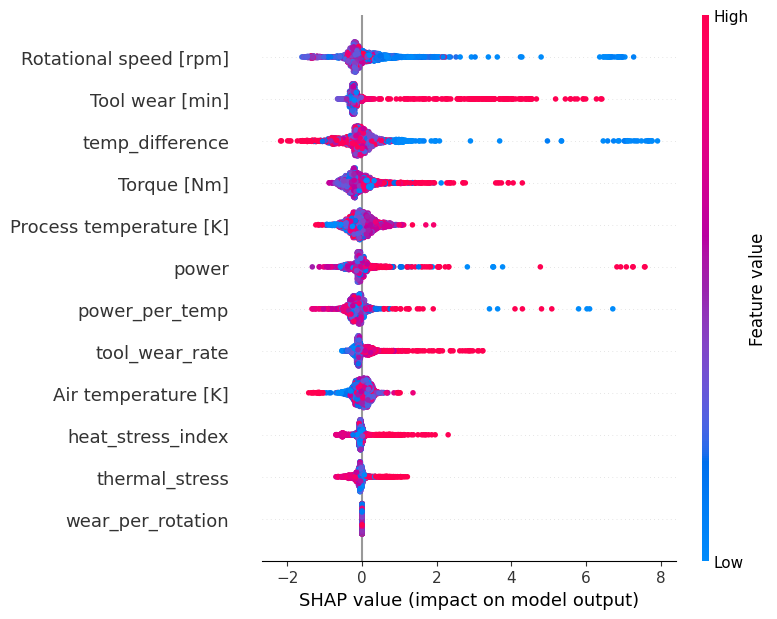

SHAP analysis complete!


In [11]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# Plot SHAP summary
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, feature_names=final_features,show=False)
plt.tight_layout()
plt.savefig(r'C:\Infoct_project 1 sample practice\Week3_Yogesh\shap_summary.png')
plt.show()
print("SHAP analysis complete!")